## Validate entrenchment sites using raw count data
This notebook attempts to validate the findings of entrenchment of specific sites (38, 55 etc) between v families or v genes using DASM using raw counts.

We do this by calculating the mutation rate on either productive or non productive data, referenced in the notebook as observed mutation rate and expected mutation rate respectively. The ratio between them should be the DNSM/DASM selection factors.

The mutation rate is calculated in the following manner:
- The rate is calculated as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites.
- rate = number of mutations / branch length per v-family, focusing on IGHV1, IGHV3, IGHV4. Branch length is calulated in three possible ways in the function: (1) number of nucleotide mutations on branch / sequence length, (2) number of synonymous nucleotide mutations on branch / sequence length, or (3) number of nonsynonymous nucleotide mutations on branch / sequence length. 
-  We chose to use the synonymous branch length version for which the results are shown here, as when we are comparing productive and non productive data, we want to calculate branch lengths using mutations that are under the same selection, and this is not true for the nonsynonymous mutations. This also gives us results that make sense for the codon mutations rates, where synonymous mutations cluster around neutral (unlike using the other two medhots, where they cluster in the positive selection area). See PR for an illustration of why this makes sense.


** The only place where this doesn't hold is the DASM comparison, where the total mutation frequency branch length looks better (closer to y=x).**

The analysis is preformed in three versions:
- per site, any mutation away from the germline - consistent with DNSM data
- per site+parent_aa+child_aa, consistent with DASM.
- per site+parent_codon+child_codon - to validate that synonymous and non synonymous mutations cluster correctly.

The calculation is performed on pcps and relies on previous code:
- For observed data (productive), site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For expected data (non productive), we adapted code from thrifty-experiments-1 to create a dataframe with the occurence of mutations per pcp pair. As non productive data has frameshifts in the VDJ recombination area, the V gene area should be consistent with the germline v gene, and so we can add IMGT numbering and germline annotations to this.

Entrenched sites, aas and v families are loaded from _output/entrenchment_analysis made in vj_families_dasm.

Results:
- Both DNSM and DASM results align with the selection factors calculated from the rates. 
- The codon rates analysis nicely shows that synonymous mutations cluster around neutral, and non synonymous mutations cover a wider range, with most of them on the negative side.
- For DASM style subsititions, many substitions do not cross the threshold of expected mutations >= 5 and have very noisy and unstable rates. When they are removed, the correlation is good (retains ~1200 out of ~4000 subsititions).
- I specifically highlighted sites that came up as interesting in the entrenchment analysis (vj_families_dasm) to make sure they are not outliers compared to the rest of the data. When they pass the filtering they are always under purifying selection with this analysis as well. 
- Substitutions that do not pass filtering is not specific to entrenched sites, but occurred at all but 3 sites of the v gene for some substitutions. All sites with entrenchment had at least one substitution that could be validated as being under purifying selection except for sites 13, 17, 18, 36, 37, 42 and 46
- We note that DASM uses a neutral mutation model that estimates expected mutation rates using a kmer-based approach rather than site-wise calculations, which may provide better predictions at these sites. We also use a smaller test dataset for this validation, which may lead to less confidence than the DASM model. We also note that the productive and non productive datasets are obtained from different individuals, which could lead to some differences in mutation patterns. However, these sites may also represent false positives in our entrenchment analysis that could arise from noise in the data and lacking model predictions.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob

from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED, CODONS, translate_codon
from netam.framework import encode_mut_pos_and_base

from shmex.shm_data import pcp_df_of_non_shmoof_nickname

from dnsmex.dasm_oe import write_sites_oe
from dnsmex.local import localify

from utils import add_column_aa_one_mutation_away_from_aa


In [2]:
# functions for comparing mutation rates across different V gene families using count data

def compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4'], branch_length_method='synonymous_mutation_freq_branch'):
    '''
    Calculate mutation rates at a specific site across different V gene families.
    Mutation rates are calculated for codon 
    
    This function analyzes mutation rates at a given site across different V families,
    using branch length as a measure of evolutionary time.
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame containing site substitution probabilities with columns:
        - 'site': site position
        - 'sample_id': sample identifier
        - 'family': family identifier
        - 'pcp_index': phylogenetic branch identifier
        - 'branch_length': evolutionary distance (substitutions per site)
        - 'germline_amino_acid': original amino acid at germline
        - 'is_germline_aa': boolean indicating if current AA matches germline
        - 'mutation': boolean indicating if site is mutated from germline
        - 'mutations_per_branch': total mutations accumulated on this branch
    
    vfamilies : list
        List of V gene families to compare (default: ['IGHV1', 'IGHV3', 'IGHV4'])
    site : int
        Site position to analyze
        
    Returns:
    --------
    list
        List of dictionaries containing mutation rate data for each V family:
        - 'vfamily': V gene family name
        - 'site': site position
        - 'branch_length': total branch length
        - 'mutations_per_branch': total mutations per branch
        - 'mutation_acquired': number of mutations acquired
        - 'rate': mutations per unit branch length
        - 'rate_mutcount': mutations per mutation count
        
    Notes:
    ------
    - Only analyzes branches where the site has germline amino acid identity
    - Handles cases with zero branch length or mutation count
    - Calculates both branch-length normalized and mutation-count normalized rates
    '''
    if branch_length_method not in ['synonymous_mutation_freq_branch', 'nonsynonymous_mutation_freq_branch', 'total_mutation_freq_branch']:
        raise ValueError("branch_length_method must be one of 'synonymous_mutation_freq_branch', 'nonsynonymous_mutation_freq_branch', or 'total_mutation_freq_branch'")
    
    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site) & (site_sub_probs_df_germline.v_family.isin(vfamilies))].copy()
    
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]

    vfamily_results = []
    vfamily_results_per_aa = []
    vfamily_results_per_codon = []

    for vfamily in vfamilies:
        # filter for the current V family and only branches that have the germline codon at site
        vfamily_df = cur_df[(cur_df['v_family'] == vfamily) & (cur_df.is_germline_codon == True)].copy()
        if vfamily_df.empty:
            print(f"No data for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates for the current V family
        length_mutcount = vfamily_df[branch_length_method].sum()

        mutation_acquired = len(vfamily_df[(vfamily_df['nucleotide_mutation_count'] > 0) & (vfamily_df['child_aa'] != vfamily_df['parent_aa'])]) # any nonsynonymous mutations

        if length_mutcount == 0:
            print(f"Zero branch length or mutation count for V family {vfamily} at site {site}")
            continue

        # Calculate mutation rates
        rate_mutcount = mutation_acquired / length_mutcount
        vfamily_results.append({
            'v_family': vfamily,
            'site': site,
            'mutcount_length': length_mutcount,
            'mutation_acquired': mutation_acquired,
            'rate_mutcount': rate_mutcount
        })


        # calculate aa specific rates
        for amino_acid in vfamily_df['germline_amino_acid'].unique():
            aa_df = vfamily_df[vfamily_df['parent_aa'] == amino_acid]
            aa_length_mutcount = aa_df[branch_length_method].sum()

            if aa_df.empty:
                continue

            for target_amino_acid in AA_STR_SORTED:
                if amino_acid != target_amino_acid:
                    aa_mutation_acquired = len(aa_df[(aa_df['nucleotide_mutation_count'] > 0) & (aa_df['child_aa'] == target_amino_acid)])
                    
                    # Calculate mutation rates for the specific amino acid
                    #rate_aa = aa_mutation_acquired / aa_length
                    rate_aa_mutcount = aa_mutation_acquired / aa_length_mutcount

                    vfamily_results_per_aa.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_aa': amino_acid,
                        'child_aa': target_amino_acid,
                        #'branch_length': aa_length,
                        'mutcount_length': aa_length_mutcount,
                        'mutation_acquired': aa_mutation_acquired,
                        #'rate': rate_aa,
                        'rate_mutcount': rate_aa_mutcount
                    })
        
         # calculate codon specific rates
        for codon in vfamily_df['germline_codon'].unique():
            codon_df = vfamily_df[vfamily_df['parent_codon'] == codon]
            codon_length_mutcount = codon_df[branch_length_method].sum()

            if codon_df.empty:
                continue

            for target_codon in CODONS:
                if codon != target_codon:
                    if sum(1 for a, b in zip(codon, target_codon) if a != b) > 1:
                        continue  # skip codons that are more than one mutation away
                    codon_mutation_acquired = len(codon_df[(codon_df['nucleotide_mutation_count'] > 0) & (codon_df['child_codon'] == target_codon)])
                    
                    # Calculate mutation rates for the specific amino acid
                    rate_codon_mutcount = codon_mutation_acquired / codon_length_mutcount

                    vfamily_results_per_codon.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_codon': codon,
                        'child_codon': target_codon,
                        'parent_aa': translate_codon(codon),
                        'child_aa': translate_codon(target_codon),
                        'mutcount_length': codon_length_mutcount,
                        'mutation_acquired': codon_mutation_acquired,
                        'rate_mutcount': rate_codon_mutcount
                    })
    
    
    return vfamily_results, vfamily_results_per_aa, vfamily_results_per_codon


def compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline, output_path, branch_length_method='synonymous_mutation_freq_branch'):
    """
    Calculate mutation rates for all sites across different V gene families.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with site substitution probabilities and germline info
        output_path (str): Base output path to save the results CSV files (without extension)
        
    Returns:
        tuple: (results_df, results_per_aa_df) - DataFrames with results for overall and per-AA analysis
    """
    import pandas as pd
    import os
    
    # Run for all sites
    all_results = []
    all_results_per_aa = []
    all_results_per_codon = []
    site_list = site_sub_probs_df_germline.site.unique().tolist()
    
    print(f"Processing {len(site_list)} sites...")
    
    for i, site in enumerate(site_list):
        if i % 10 == 0:  # Progress indicator
            print(f"Processing site {i+1}/{len(site_list)}: site {site}")
            
        vfamily_results, vfamily_results_per_aa, vfamily_results_per_codon = compare_mutation_rates_on_different_vfamilies(
            site_sub_probs_df_germline, site, branch_length_method=branch_length_method
        )
        
        # Extend the lists with results from this site
        all_results.extend(vfamily_results)
        all_results_per_aa.extend(vfamily_results_per_aa)
        all_results_per_codon.extend(vfamily_results_per_codon)

    # Convert to DataFrames
    print("Converting results to DataFrames...")
    results_df = pd.DataFrame(all_results)
    results_per_aa_df = pd.DataFrame(all_results_per_aa)
    results_per_codon_df = pd.DataFrame(all_results_per_codon)
    
    # Generate output file paths
    base_path = output_path.replace('.csv', '')  # Remove .csv if present
    overall_output_path = f"{base_path}_overall_mutation_rates.csv"
    per_aa_output_path = f"{base_path}_per_aa_mutation_rates.csv"
    per_codon_output_path = f"{base_path}_per_codon_mutation_rates.csv"
    
    # Save overall results
    if not results_df.empty:
        print(f'Saving overall results to {overall_output_path}')
        results_df.to_csv(overall_output_path, index=False)
        print(f"Overall results: {len(results_df)} rows saved")
    else:
        print("Warning: No overall results to save")
    
    # Save per-amino acid results  
    if not results_per_aa_df.empty:
        print(f'Saving per-amino acid results to {per_aa_output_path}')
        results_per_aa_df.to_csv(per_aa_output_path, index=False)
        print(f"Per-AA results: {len(results_per_aa_df)} rows saved")
    else:
        print("Warning: No per-amino acid results to save")

    # Save per-codon results
    if not results_per_codon_df.empty:
        print(f'Saving per-codon results to {per_codon_output_path}')
        results_per_codon_df.to_csv(per_codon_output_path, index=False)
        print(f"Per-codon results: {len(results_per_codon_df)} rows saved")
    else:
        print("Warning: No per-codon results to save")
    
    return results_df, results_per_aa_df, results_per_codon_df


In [3]:
### prepare shm out of frame data
### adapted from thrifty-experiments-1

data_nickname = "tangshm"
#data_nickname = 'shmoof'
dest_dir = "_ignore/expected_counts_from_non_productive"
os.makedirs(dest_dir, exist_ok=True)

def ragged_np_pcp_encoding(parents, children, site_count=None):
    """
    Encode the mutation indicators, base indices, and masks of a list of
    parent-child pairs.
    """
    mutation_indicator_list = []
    mask_list = []
    for parent, child in zip(parents, children):
        mutation_indicators, _ = encode_mut_pos_and_base(parent, child)
        mutation_indicator_list.append(mutation_indicators.numpy()[:site_count])
        mask_list.append(nt_mask_tensor_of(child).numpy()[:site_count])
    return mutation_indicator_list, mask_list


def detailed_site_df_for(pcp_df):
    """Create a DataFrame with every site, mutation status, branch length, v_gene, and sequence details"""
    mut_indicators, masks = ragged_np_pcp_encoding(
        pcp_df["parent"], pcp_df["child"]
    )
    val_bls = pcp_df["branch_length"].values
    
    detailed_rows = []
    
    for seq_idx, (mask, branch_length, mut_indicator, v_gene, parent_seq, child_seq) in enumerate(
        zip(masks, val_bls, mut_indicators, pcp_df["v_gene"], pcp_df["parent"], pcp_df["child"])
    ):
        
        # For each site in this sequence
        for site_idx in range(len(parent_seq)):
            if mask[site_idx]:  # Only include valid sites
                # Get nucleotides
                parent_nt = parent_seq[site_idx] if site_idx < len(parent_seq) else 'N'
                child_nt = child_seq[site_idx] if site_idx < len(child_seq) else 'N'
                
                # Get codon information (which codon this site belongs to)
                codon_idx = (site_idx // 3)
                codon_position = site_idx % 3  # Position within codon (0, 1, or 2)
                
                # Extract parent and child codons
                codon_start = codon_idx * 3
                codon_end = codon_start + 3
                
                parent_codon = parent_seq[codon_start:codon_end] if codon_end <= len(parent_seq) else 'NNN'
                child_codon = child_seq[codon_start:codon_end] if codon_end <= len(child_seq) else 'NNN'
                
                # Translate codons to amino acids
                try:
                    from Bio.Seq import Seq
                    parent_aa = str(Seq(parent_codon).translate()) if len(parent_codon) == 3 else 'X'
                    child_aa = str(Seq(child_codon).translate()) if len(child_codon) == 3 else 'X'
                except:
                    parent_aa = 'X'
                    child_aa = 'X'
                
                detailed_rows.append({
                    'pcp_index': seq_idx,
                    'nt_site': site_idx,
                    'site': codon_idx + 1,
                    'codon_position': codon_position,
                    'mutation': bool(mut_indicator[site_idx]),
                    'branch_length': branch_length,
                    'v_gene': v_gene,
                    'v_family': v_gene.split('-')[0] if '-' in str(v_gene) else v_gene,
                    'parent_nt': parent_nt,
                    'child_nt': child_nt,
                    'parent_codon': parent_codon,
                    'child_codon': child_codon,
                    'parent_aa': parent_aa,
                    'child_aa': child_aa,
                })
    
    return pd.DataFrame(detailed_rows)


def create_detailed_site_data(
    dataset_name,
):
    """
    Create detailed site-level data with mutation probabilities and observed mutations.
    
    Returns:
    - pcp_df: The parent-child pair DataFrame
    - detailed_site_df: DataFrame with every site and its mutation data
    """
    pcp_df = pcp_df_of_non_shmoof_nickname(dataset_name)

    # Create detailed site data for all sequences
    detailed_site_list = []
    
    # All data
    detailed_all = detailed_site_df_for(pcp_df)
    detailed_site_list.append(detailed_all)
    
    # Combine all detailed data
    detailed_site_df = pd.concat(detailed_site_list, ignore_index=True)
    
    # add germline information
    ## Non producive pcps are only out of frame in the VDJ junction, as sequences with indels acquired during affinity maturation are filtered out.
    ## Consequently, the V gene part of the sequence is always in frame and can be compared to the germline V gene sequence.
    ## germline_codons_df is also IMGT aligned so we use that to get IMGT alignemnt for the non prouctive sequences.
    germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False)['site'].rank(method='dense').astype(int)
    detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank', 'mutation_occurred':'mutation'}), germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}), on=['v_family', 'v_gene', 'rank'], how='left')
    detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['germline_codon']
    detailed_site_df_germline['is_germline_aa'] = detailed_site_df_germline['parent_aa'] == detailed_site_df_germline['germline_amino_acid']

    # remove rows with N in parent or child codon
    detailed_site_df_germline = detailed_site_df_germline[(~detailed_site_df_germline.parent_codon.str.contains('N')) & (~detailed_site_df_germline.child_codon.str.contains('N'))]

    # collapse nucleotide to site level analysis
    detailed_site_df_germline_per_site = detailed_site_df_germline[['pcp_index',
       'branch_length', 'v_gene', 'v_family',
       'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'site',
       'germline_codon', 'germline_amino_acid', 'is_germline_codon',
       'is_germline_aa', 'rank']].drop_duplicates().sort_values(by=['pcp_index', 'site']).drop(columns='rank')


    # nucleotide mutations frequency per branch as an alternative to branch length
    detailed_site_df_germline_per_site['seq_nuc_length'] = detailed_site_df_germline_per_site.groupby('pcp_index').transform('size') * 3  # nucleotide length

    detailed_site_df_germline_per_site['nucleotide_mutation_count'] = detailed_site_df_germline_per_site.apply(lambda row: sum(c1 != c2 for c1, c2 in zip(row['child_codon'], row['parent_codon'])), axis=1)
    detailed_site_df_germline_per_site['mutation'] = detailed_site_df_germline_per_site['parent_aa'] != detailed_site_df_germline_per_site['child_aa']

    detailed_site_df_germline_per_site['synonymous_nucleotide_mutation_count'] = np.where(
        detailed_site_df_germline_per_site['mutation'] == False,
        detailed_site_df_germline_per_site['nucleotide_mutation_count'],
        0)
    detailed_site_df_germline_per_site['nonsynonymous_nucleotide_mutation_count'] = np.where(
        detailed_site_df_germline_per_site['mutation'] == True,
        detailed_site_df_germline_per_site['nucleotide_mutation_count'],
        0)
    
    detailed_site_df_germline_per_site['synonymous_mutations_per_branch'] = detailed_site_df_germline_per_site.groupby('pcp_index')['synonymous_nucleotide_mutation_count'].transform('sum')
    detailed_site_df_germline_per_site['nonsynonymous_mutations_per_branch'] = detailed_site_df_germline_per_site.groupby('pcp_index')['nonsynonymous_nucleotide_mutation_count'].transform('sum')
    detailed_site_df_germline_per_site['total_mutations_per_branch'] = detailed_site_df_germline_per_site['nonsynonymous_mutations_per_branch'] + detailed_site_df_germline_per_site['synonymous_mutations_per_branch']  # should equal total mutations per branch

    detailed_site_df_germline_per_site['synonymous_mutation_freq_branch'] = detailed_site_df_germline_per_site['synonymous_mutations_per_branch'] / detailed_site_df_germline_per_site['seq_nuc_length']
    detailed_site_df_germline_per_site['nonsynonymous_mutation_freq_branch'] = detailed_site_df_germline_per_site['nonsynonymous_mutations_per_branch'] / detailed_site_df_germline_per_site['seq_nuc_length']
    detailed_site_df_germline_per_site['total_mutation_freq_branch'] = detailed_site_df_germline_per_site['total_mutations_per_branch'] / detailed_site_df_germline_per_site['seq_nuc_length']
    
    return pcp_df, detailed_site_df_germline, detailed_site_df_germline_per_site


# Create the detailed site data
pcp_df_neutral, detailed_nuc_site_df_neutral, detailed_site_df_neutral = create_detailed_site_data(
    dataset_name=data_nickname,
)

Loading /home/nharel/data/v1/tang-deepshm-oof_pcp_2024-04-09_MASKED_NI.csv.gz
Loaded 7000 PCPs from tangshm


In [4]:
## load and prepare data for observed mutation rates using counts


def load_or_create_datafile(dataset_name, remove_leaves=True):
    model_name = "dnsm_1m-v1jaffe+v1tang-joint"

    crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

    try:
        site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
        pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


    except FileNotFoundError:
        if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
            dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


        complete_plotter, plotter_dict = write_sites_oe(
            crepe_prefix=crepe_prefix,
            dataset_name=dataset_name,
            branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
            csv_output_path=f"{test_output_prefix}-sites-oe.csv",
            fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
            min_log_prob=-4,
            replace_title=True,
        )
        complete_plotter = complete_plotter["heavy"]


        pcp_df = complete_plotter.pcp_df.copy()
        site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
        for column_name in ['selection_factor', 'neutral_prob', 'prob']:
            site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


        pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
        site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name', 'child_is_leaf']]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

    site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
    site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
    site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon

    # nucleotide mutations frequency per branch as an alternative to branch length
    site_sub_probs_df_germline['seq_nuc_length'] = site_sub_probs_df_germline.groupby('pcp_index').transform('size') * 3  # nucleotide length

    site_sub_probs_df_germline['nucleotide_mutation_count'] = site_sub_probs_df_germline.apply(lambda row: sum(c1 != c2 for c1, c2 in zip(row['child_codon'], row['parent_codon'])), axis=1)
    site_sub_probs_df_germline['mutation'] = site_sub_probs_df_germline['parent_aa'] != site_sub_probs_df_germline['child_aa']

    site_sub_probs_df_germline['synonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == False,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)
    site_sub_probs_df_germline['nonsynonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == True,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)
    
    site_sub_probs_df_germline['synonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['synonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['nonsynonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['total_mutations_per_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] + site_sub_probs_df_germline['synonymous_mutations_per_branch']  # should equal total mutations per branch

    site_sub_probs_df_germline['synonymous_mutation_freq_branch'] = site_sub_probs_df_germline['synonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['nonsynonymous_mutation_freq_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['total_mutation_freq_branch'] = site_sub_probs_df_germline['total_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']


    
    if remove_leaves:
        print("Removing leaf nodes from the analysis")
        site_sub_probs_df_germline = site_sub_probs_df_germline[~site_sub_probs_df_germline['child_is_leaf']]

    return site_sub_probs_df_germline, pcp_df


site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1rodriguez')

#site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1tang')


Removing leaf nodes from the analysis


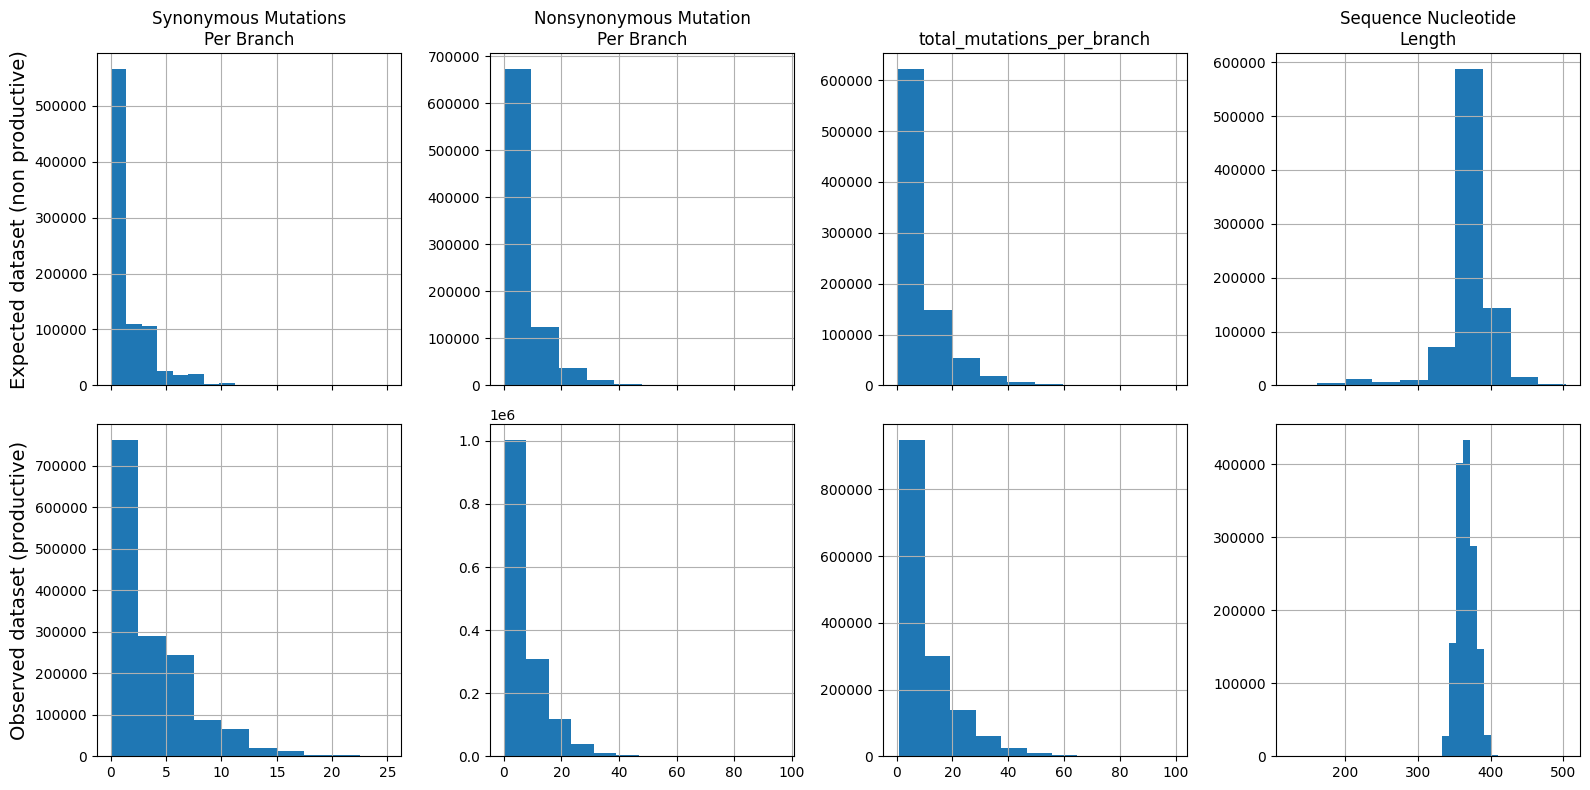

In [5]:
# statistics about the two datasets - how many mutations of each type per branch

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex='col')

columns = ['synonymous_mutations_per_branch', 
           'nonsynonymous_mutations_per_branch', 'total_mutations_per_branch', 'seq_nuc_length']
titles = ['Synonymous Mutations\nPer Branch', 'Nonsynonymous Mutation\nPer Branch', 
          'total_mutations_per_branch', 'Sequence Nucleotide\nLength']

# First dataset
for i, (col, title) in enumerate(zip(columns, titles)):
    detailed_site_df_neutral[col].hist(ax=axes[0, i])
    axes[0, i].set_title(title)
    if i == 0:
        axes[0, i].set_ylabel('Expected dataset (non productive)', fontsize=14)

# Second dataset
for i, col in enumerate(columns):
    site_sub_probs_df_germline_total[col].hist(ax=axes[1, i])
    if i == 0:
        axes[1, i].set_ylabel('Observed dataset (productive)', fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
## calculate observed and expected mutation rates

output_dirs = '_ignore/observed_counts_from_productive', '_ignore/expected_counts_from_non_productive'

for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)

compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total,  '_ignore/observed_counts_from_productive/observed_mutation_rates.csv', branch_length_method='synonymous_mutation_freq_branch')
compare_mutation_rates_on_different_backgrounds_for_all_sites(detailed_site_df_neutral,  '_ignore/expected_counts_from_non_productive/expected_mutation_rates.csv', branch_length_method='synonymous_mutation_freq_branch')

Processing 144 sites...
Processing site 1/144: site 1.0
Processing site 11/144: site 12.0
Processing site 21/144: site 22.0
No data for V family IGHV1 at site 31.0
No data for V family IGHV3 at site 31.0
Processing site 31/144: site 34.0
No data for V family IGHV1 at site 34.0
No data for V family IGHV3 at site 34.0
Processing site 41/144: site 44.0
Processing site 51/144: site 54.0
No data for V family IGHV1 at site 60.0
No data for V family IGHV4 at site 60.0
No data for V family IGHV1 at site 61.0
No data for V family IGHV4 at site 61.0
No data for V family IGHV4 at site 62.0
Processing site 61/144: site 64.0
Processing site 71/144: site 75.0
Processing site 81/144: site 85.0
Processing site 91/144: site 95.0
Processing site 101/144: site 105.0
No data for V family IGHV1 at site 107.0
No data for V family IGHV4 at site 107.0
No data for V family IGHV1 at site 108.0
No data for V family IGHV3 at site 108.0
No data for V family IGHV4 at site 108.0
No data for V family IGHV1 at site 10

(    v_family   site  mutcount_length  mutation_acquired  rate_mutcount
 0      IGHV1    1.0         5.229536                 11       2.103437
 1      IGHV3    1.0        11.336648                106       9.350207
 2      IGHV4    1.0         5.573741                 13       2.332365
 3      IGHV1    2.0         4.637853                 19       4.096723
 4      IGHV3    2.0        11.294518                 48       4.249849
 ..       ...    ...              ...                ...            ...
 293    IGHV3   60.0         1.076101                 27      25.090578
 294    IGHV3   61.0         0.960288                 12      12.496251
 295    IGHV4   31.0         2.396390                 39      16.274477
 296    IGHV4   34.0         1.985426                 25      12.591754
 297    IGHV3  107.0         0.267459                  6      22.433321
 
 [298 rows x 5 columns],
       v_family   site parent_aa child_aa  mutcount_length  mutation_acquired  \
 0        IGHV1    1.0      

## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Below, when we higlight entrenched sites in the scatter plots, we have one version for all sites and then one version for the within v family entrenched sites, as those are the more surprising ones that we wanted to focus on in validation.


In [7]:
#Load entrenched sites, "within" files and "vs" files separately
within_dfs = []
vs_dfs = []

within_files = glob.glob('_output/entrenchment_analysis/entrenched_aa_sites*within*.csv')
vs_files = glob.glob('_output/entrenchment_analysis/entrenched_aa_sites*vs*.csv')


for f in within_files:
    df = pd.read_csv(f)
    within_dfs.append(df)
for f in vs_files:
    df = pd.read_csv(f)
    vs_dfs.append(df)

within_dfs = pd.concat(within_dfs, ignore_index=True)
vs_dfs = pd.concat(vs_dfs, ignore_index=True)


within_sites = within_dfs[['site', 'v_family']].drop_duplicates()
vs_sites = vs_dfs[['site', 'v_family']].drop_duplicates()
within_sites_aas = within_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()
vs_sites_aas = vs_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()


entrenched_sites = pd.concat([within_sites, vs_sites]).drop_duplicates().sort_values(['site', 'v_family'])
entrenched_sites_aas = pd.concat([within_sites_aas, vs_sites_aas]).drop_duplicates().sort_values(['site', 'v_family', 'amino_acid', 'target_amino_acid'])
print(len(entrenched_sites))
print(len(entrenched_sites_aas))



##### pairwise comparisons
pairwise_files = glob.glob('_output/entrenchment_analysis/comparison*vs*.csv')
pairwise_df_dict = {}
for f in pairwise_files:
    pairwise_df_dict[f.split('/')[-1].replace('comparison_', '').replace('.csv', '')] = pd.read_csv(f)




###### Create consistent color palette for entrenched sites
# Get all unique sites from your entrenched data
all_entrenched_sites = sorted(entrenched_sites_aas['site'].unique())

# Create the full palette
full_palette = sns.color_palette("tab20") + sns.color_palette("tab20b")[:5]

# Create a dictionary mapping each site to its color
SITE_COLOR_MAP = {str(site): full_palette[i] for i, site in enumerate(all_entrenched_sites)}

print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")


55
130
Created color mapping for 23 sites


## Rates per site (any germline aa to any aa)
- First let's compare do DNSM to see that this makes sense.
- Second - look at entrenched sites (38, 55 etc). They seem to have a very high expected rate, together with a pretty low observed mutation rate.


In [8]:
observed_df = pd.read_csv('_ignore/observed_counts_from_productive/observed_mutation_rates_overall_mutation_rates.csv')
expected_df = pd.read_csv('_ignore/expected_counts_from_non_productive/expected_mutation_rates_overall_mutation_rates.csv')

In [9]:
# compare dnsm log selection factors and log rate ratio of counts (observed / expected)
# aggregate by v_family and site

dnsm_summarized = site_sub_probs_df_germline_total[site_sub_probs_df_germline_total.is_germline_aa == True].groupby(['v_family', 'site']).selection_factor.median().reset_index()
dnsm_summarized['log_selection_factor'] = np.log(dnsm_summarized['selection_factor'])
dnsm_summarized['log_selection_factor'] = dnsm_summarized['log_selection_factor'].clip(lower=-4, upper=4)

rates_summarized = pd.merge(
    observed_df[['v_family', 'site', 'mutcount_length','mutation_acquired','rate_mutcount']],
    expected_df[['v_family', 'site', 'mutcount_length','mutation_acquired','rate_mutcount']],
    on=['site', 'v_family'],
    suffixes=('_observed', '_expected')
)

rates_summarized['ratio'] = (rates_summarized['rate_mutcount_observed'] + 1e-3) / (rates_summarized['rate_mutcount_expected'] + 1e-3)
rates_summarized['log_ratio'] = np.log(rates_summarized['ratio'])
rates_summarized['log_ratio'] = rates_summarized['log_ratio'].clip(lower=-4, upper=4)

compare_rates_dnsm = pd.merge(rates_summarized, dnsm_summarized, on=['v_family', 'site'])


Text(0.5, 1.0, 'Log Rate Ratio Distribution (germline amino acid to any other amino acid)')

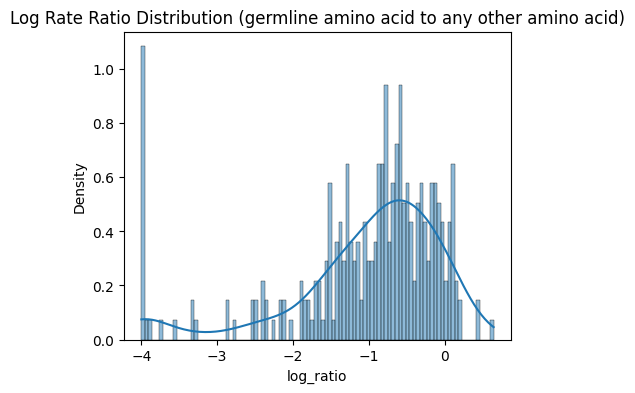

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(rates_summarized.log_ratio, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
ax.set_title('Log Rate Ratio Distribution (germline amino acid to any other amino acid)')


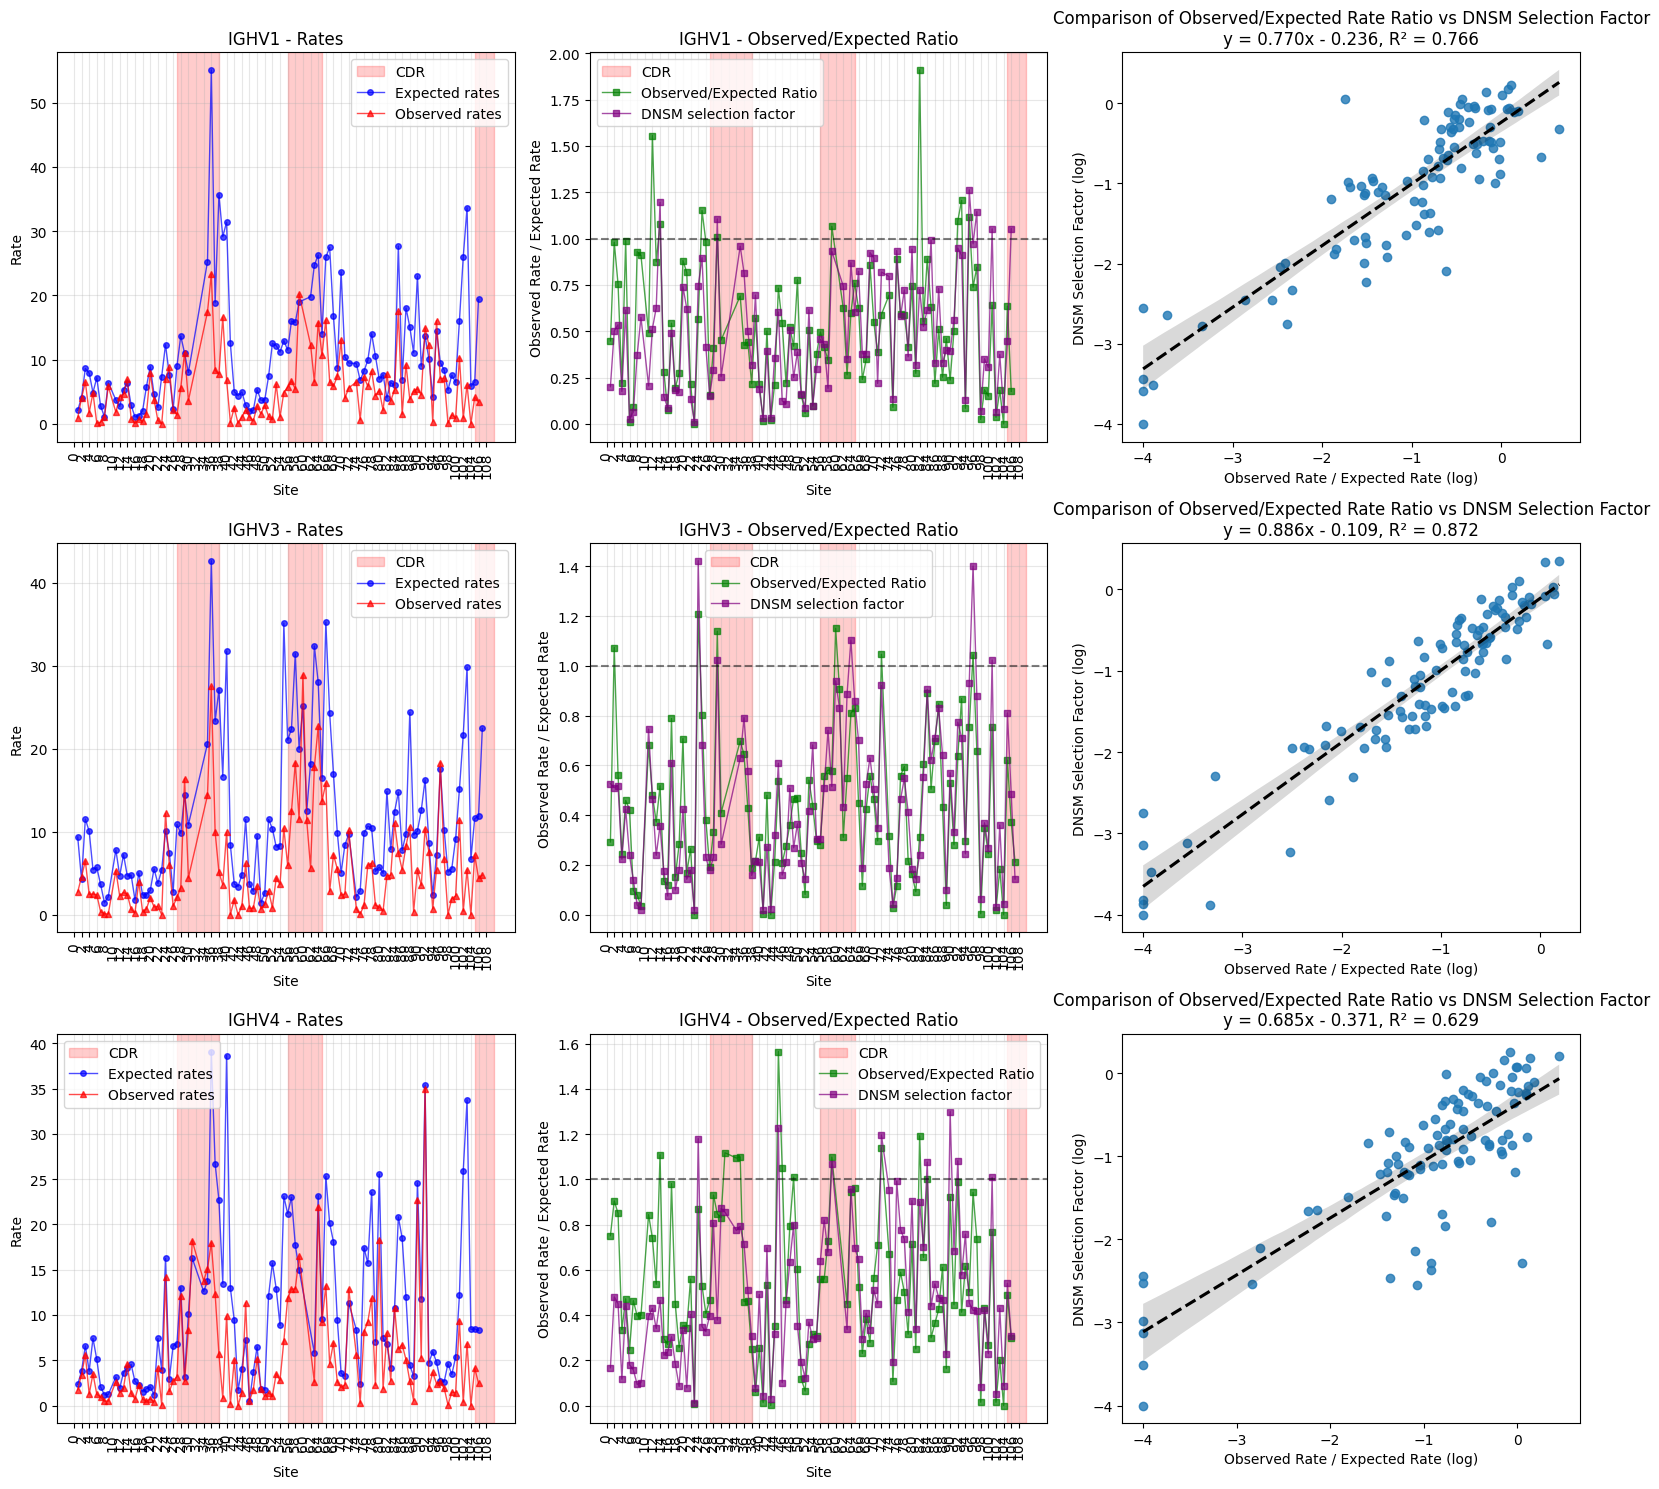

In [11]:
# plot the rates and rate ratio (observed / expected) for each v_family


fig, axes = plt.subplots(3, 3, figsize=(16, 15))
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

# Define CDR regions (approximate IMGT positions)
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (approximate, can vary) (shortened, just because looking nonly at v genes)
]

for i, v_family in enumerate(v_families):
    # Left column - rates
    ax_rates = axes[i, 0]

    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        ax_rates.axvspan(cdr_start, cdr_end, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")

    # Filter and sort data for this v_family
    compare_rates_dnsm_family = compare_rates_dnsm[compare_rates_dnsm['v_family'] == v_family].sort_values('site')
    #expected_df_family = expected_df[expected_df['v_family'] == v_family].sort_values('site')
    #observed_df_family = observed_df[observed_df['v_family'] == v_family].sort_values('site')

    # Plot expected rates
    ax_rates.plot(compare_rates_dnsm_family['site'], compare_rates_dnsm_family['rate_mutcount_expected'],
           'o-', alpha=0.7, label='Expected rates', color='blue', markersize=4, linewidth=1)

    # Plot observed rates
    ax_rates.plot(compare_rates_dnsm_family['site'], compare_rates_dnsm_family['rate_mutcount_observed'],
           '^-', alpha=0.7, label='Observed rates', color='red', markersize=4, linewidth=1)

    # Formatting for rates column
    ax_rates.set_title(f'{v_family} - Rates')
    ax_rates.set_xlabel('Site')
    ax_rates.set_ylabel('Rate')
    ax_rates.legend()
    ax_rates.grid(True, alpha=0.3)

    # Set x-ticks every second value and rotate labels
    if len(compare_rates_dnsm_family) > 0:
        ax_rates.set_xticks(np.arange(0, 110, 2))  # Every second site
        ax_rates.tick_params(axis='x', rotation=90)  # Rotate x-tick labels

    # Middle column - ratio
    ax_ratio = axes[i, 1]

    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        ax_ratio.axvspan(cdr_start, cdr_end, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")

    # Plot ratio and DNSM
    ax_ratio.plot(compare_rates_dnsm_family['site'], compare_rates_dnsm_family['ratio'],
           's-', alpha=0.7, color='green', markersize=4, linewidth=1, label='Observed/Expected Ratio')
    ax_ratio.plot(compare_rates_dnsm_family['site'], compare_rates_dnsm_family['selection_factor'],
            's-', alpha=0.7, color='purple', markersize=4, linewidth=1, label='DNSM selection factor')
    ax_ratio.legend()
    # Add horizontal line at y=1 for reference
    ax_ratio.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # Formatting for ratio column
    ax_ratio.set_title(f'{v_family} - Observed/Expected Ratio')
    ax_ratio.set_xlabel('Site')
    ax_ratio.set_ylabel('Observed Rate / Expected Rate')
    ax_ratio.grid(True, alpha=0.3)

    # Set x-ticks every second value and rotate labels
    if len(compare_rates_dnsm_family) > 0:
        ax_ratio.set_xticks(np.arange(0, 110, 2))  # Every second site
        ax_ratio.tick_params(axis='x', rotation=90)  # Rotate x-tick labels


    # Right column - correlation
    ax_correlation = axes[i, 2]

    sns.regplot(data=compare_rates_dnsm_family, x='log_ratio', y='log_selection_factor', 
            scatter=True, line_kws={'linestyle': '--', 'color': 'black'}, ax=ax_correlation)


    ax_correlation.set_xlabel('Observed Rate / Expected Rate (log)')
    ax_correlation.set_ylabel('DNSM Selection Factor (log)')

    # Format the equation and R² for the title
    # Calculate regression statistics
    x = compare_rates_dnsm_family['log_ratio']
    y = compare_rates_dnsm_family['log_selection_factor']

    # Remove any NaN values for regression calculation
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value ** 2
    if intercept >= 0:
        equation = f'y = {slope:.3f}x + {intercept:.3f}'
    else:
        equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

    title = f'Comparison of Observed/Expected Rate Ratio vs DNSM Selection Factor\n{equation}, R² = {r_squared:.3f}'
    ax_correlation.set_title(title)


plt.tight_layout()
plt.show()

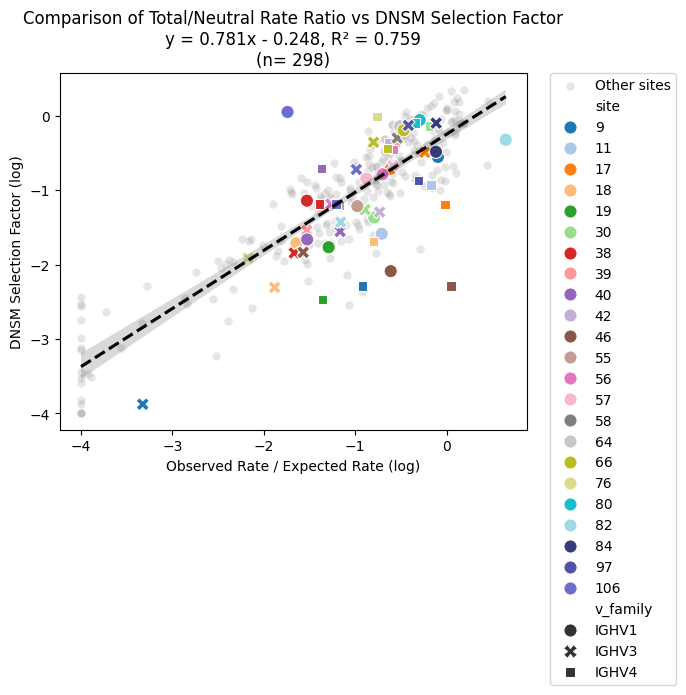

In [13]:
# Highlight all entrenched sites


# Calculate regression statistics
x = compare_rates_dnsm['log_ratio']
y = compare_rates_dnsm['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2
n_regression = len(x_clean)


# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot regular points in grey
sns.scatterplot(data=compare_rates_dnsm, 
                x='log_ratio', y='log_selection_factor', 
                color='grey', alpha=0.2, label='Other sites')


# filter entrenched data
entrenched_compare_rates_dnsm = pd.merge(entrenched_sites, compare_rates_dnsm, on=['site', 'v_family'], how='inner')
# plot entrenched points in color
entrenched_compare_rates_dnsm['site'] = entrenched_compare_rates_dnsm['site'].astype(str)
sns.scatterplot(data=entrenched_compare_rates_dnsm,
                x='log_ratio', y='log_selection_factor', 
                s=90, hue='site', style='v_family', palette=SITE_COLOR_MAP)

# Add the regression line
sns.regplot(data=compare_rates_dnsm, x='log_ratio', y='log_selection_factor', 
            scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

# Add legend
plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


plt.xlabel('Observed Rate / Expected Rate (log)')
plt.ylabel('DNSM Selection Factor (log)')

# Format the equation and R² for the title
if intercept >= 0:
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
else:
    equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

title = f'Comparison of Total/Neutral Rate Ratio vs DNSM Selection Factor\n{equation}, R² = {r_squared:.3f}\n(n= {n_regression})'
plt.title(title)

plt.tight_layout()
plt.show()

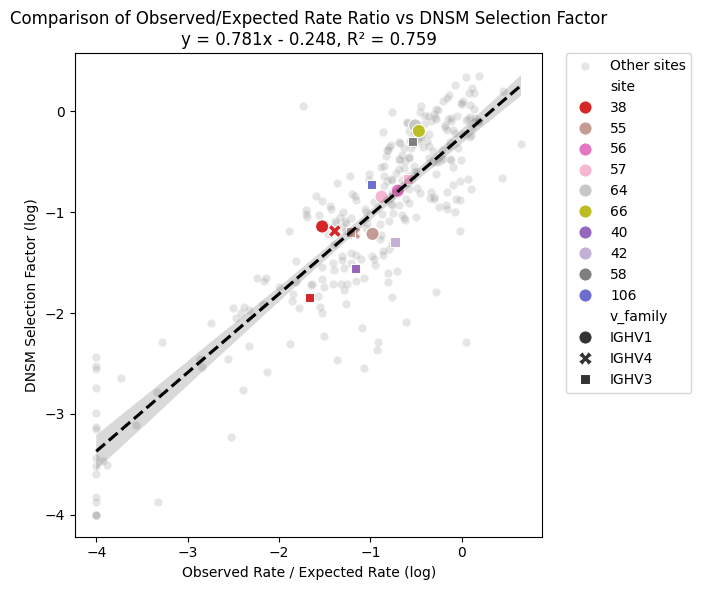

In [14]:
# Highlight within v family entrenched sites


compare_rates_dnsm = pd.merge(rates_summarized, dnsm_summarized, on=['v_family', 'site'])

# Calculate regression statistics
x = compare_rates_dnsm['log_ratio']
y = compare_rates_dnsm['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2

# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))


# Plot regular points in grey
sns.scatterplot(data=compare_rates_dnsm,
                x='log_ratio', y='log_selection_factor',
                color='grey', alpha=0.2, label='Other sites')

# filter entrenched data
entrenched_compare_rates_dnsm = pd.merge(within_sites, compare_rates_dnsm, on=['site', 'v_family'], how='inner')
# plot entrenched points in color
entrenched_compare_rates_dnsm['site'] = entrenched_compare_rates_dnsm['site'].astype(str)
sns.scatterplot(data=entrenched_compare_rates_dnsm,
                x='log_ratio', y='log_selection_factor',
                s=90, hue='site', style='v_family', palette=SITE_COLOR_MAP)

# Add the regression line
sns.regplot(data=compare_rates_dnsm, x='log_ratio', y='log_selection_factor',
            scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

# Add legend
plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


plt.xlabel('Observed Rate / Expected Rate (log)')
plt.ylabel('DNSM Selection Factor (log)')

# Format the equation and R² for the title
if intercept >= 0:
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
else:
    equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

title = f'Comparison of Observed/Expected Rate Ratio vs DNSM Selection Factor\n{equation}, R² = {r_squared:.3f}'
plt.title(title)

plt.tight_layout()
plt.show()

## Rates per site, parent codon and child codon
- Let's use these rates to examine synoymous and non synonymous mutation differences. We expect synonymous mutations log rate ratio to cluster around 0, while the non synonymous log rate ratio will mostly be lower than 0.

In [15]:
observed_codon_df = pd.read_csv('_ignore/observed_counts_from_productive/observed_mutation_rates_per_codon_mutation_rates.csv')
expected_codon_df = pd.read_csv('_ignore/expected_counts_from_non_productive/expected_mutation_rates_per_codon_mutation_rates.csv')

In [16]:
# Merge data to calculate ratios at matching sites and AA changes
rates_codons_summarized = pd.merge(
        observed_codon_df[['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'rate_mutcount', 'mutcount_length', 'mutation_acquired', 'v_family']],
        expected_codon_df[['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'rate_mutcount',  'mutcount_length', 'mutation_acquired', 'v_family']],
        on=['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'v_family'],
        suffixes=('_observed', '_expected')
    )

rates_codons_summarized['ratio'] = (rates_codons_summarized['rate_mutcount_observed'] + 1e-3) / (rates_codons_summarized['rate_mutcount_expected'] + 1e-3)
rates_codons_summarized['log_ratio'] = np.log(rates_codons_summarized['ratio'])

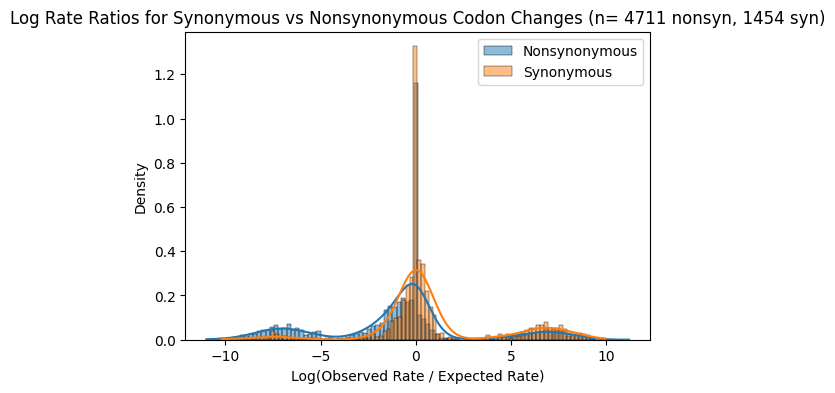

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa != rates_codons_summarized.child_aa)
].log_ratio

synonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa == rates_codons_summarized.child_aa)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100)

ax.legend()
ax.set_xlabel('Log(Observed Rate / Expected Rate)')
ax.set_title('Log Rate Ratios for Synonymous vs Nonsynonymous Codon Changes (n= {} nonsyn, {} syn)'.format(len(nonsynonymous), len(synonymous)))
plt.show()

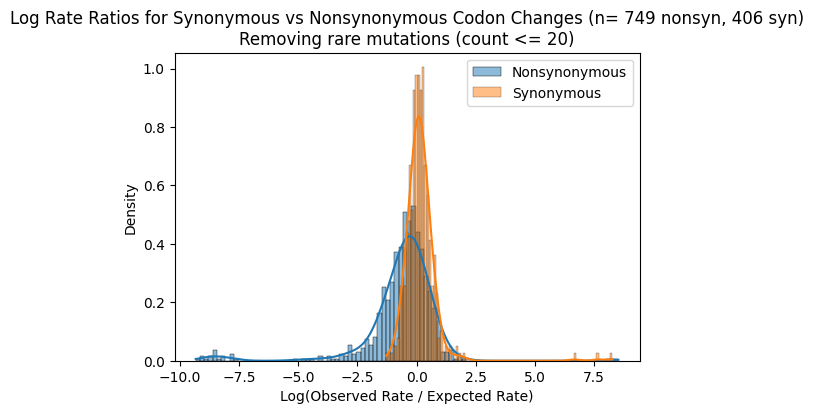

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa != rates_codons_summarized.child_aa) &
    (rates_codons_summarized['mutation_acquired_observed'] + rates_codons_summarized['mutation_acquired_expected'] > 20)
].log_ratio

synonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa == rates_codons_summarized.child_aa) &
    (rates_codons_summarized['mutation_acquired_observed'] + rates_codons_summarized['mutation_acquired_expected'] > 20)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100)

ax.legend()
ax.set_xlabel('Log(Observed Rate / Expected Rate)')
ax.set_title('Log Rate Ratios for Synonymous vs Nonsynonymous Codon Changes (n= {} nonsyn, {} syn)\nRemoving rare mutations (count <= 20)'.format(len(nonsynonymous), len(synonymous)))

plt.show()

## Rates per site, parent aa and child aa
- First let's compare to DASM to see that this makes sense.
- Second - look at interesting sites (38, 55 etc). And see that they line up.


In [19]:
observed_aa_df = pd.read_csv('_ignore/observed_counts_from_productive/observed_mutation_rates_per_aa_mutation_rates.csv')
expected_aa_df = pd.read_csv('_ignore/expected_counts_from_non_productive/expected_mutation_rates_per_aa_mutation_rates.csv')

add_column_aa_one_mutation_away_from_aa(observed_aa_df, 'parent_aa', 'child_aa')
add_column_aa_one_mutation_away_from_aa(expected_aa_df, 'parent_aa', 'child_aa')

Adding one_mutation_away column:   0%|          | 0/10298 [00:00<?, ?it/s]

Adding one_mutation_away column: 100%|██████████| 10279/10279 [00:00<00:00, 233000.52it/s]


In [20]:
# Merge data to calculate ratios at matching sites and AA changes
rates_aa_summarized = pd.merge(
        observed_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount', 'mutcount_length', 'mutation_acquired', 'v_family', 'one_mutation_away']],
        expected_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount',  'mutcount_length', 'mutation_acquired', 'v_family', 'one_mutation_away']],
        on=['site', 'parent_aa', 'child_aa', 'v_family', 'one_mutation_away'],
        suffixes=('_observed', '_expected')
    )

rates_aa_summarized['ratio'] = (rates_aa_summarized['rate_mutcount_observed'] + 1e-3) / (rates_aa_summarized['rate_mutcount_expected'] + 1e-3)
rates_aa_summarized['log_ratio'] = np.log(rates_aa_summarized['ratio'])

Text(0.5, 1.0, 'Log Rate Ratio Distribution (amino acid to amino acid)\nRemoving rare mutations (count <= 20)')

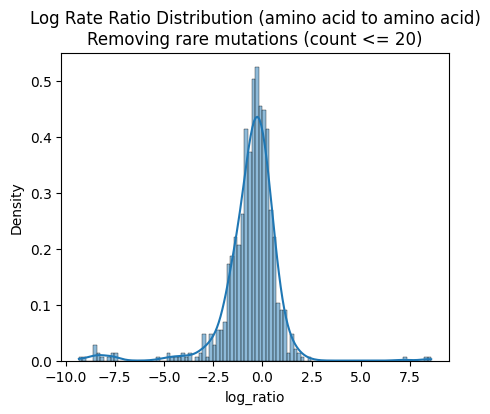

In [21]:

fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(rates_aa_summarized[(rates_aa_summarized['mutation_acquired_observed'] + rates_aa_summarized['mutation_acquired_expected'] > 20)].log_ratio, ax=ax, kde=True, stat='density', alpha=0.5, bins=100)
ax.set_title('Log Rate Ratio Distribution (amino acid to amino acid)\nRemoving rare mutations (count <= 20)')


In [22]:
### load DASM for comparison

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)


# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'depth', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)
## add germline information
germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))
germline_codons_df['site'] = germline_codons_df['site'].astype(float)
aa_site_subs_selection_df_germline = pd.merge(aa_site_subs_selection_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
aa_site_subs_selection_df_germline['is_germline_aa'] = aa_site_subs_selection_df_germline.parent_aa == aa_site_subs_selection_df_germline.germline_amino_acid
aa_site_subs_selection_df_germline['is_germline_codon'] = aa_site_subs_selection_df_germline.parent_codon == aa_site_subs_selection_df_germline.germline_codon


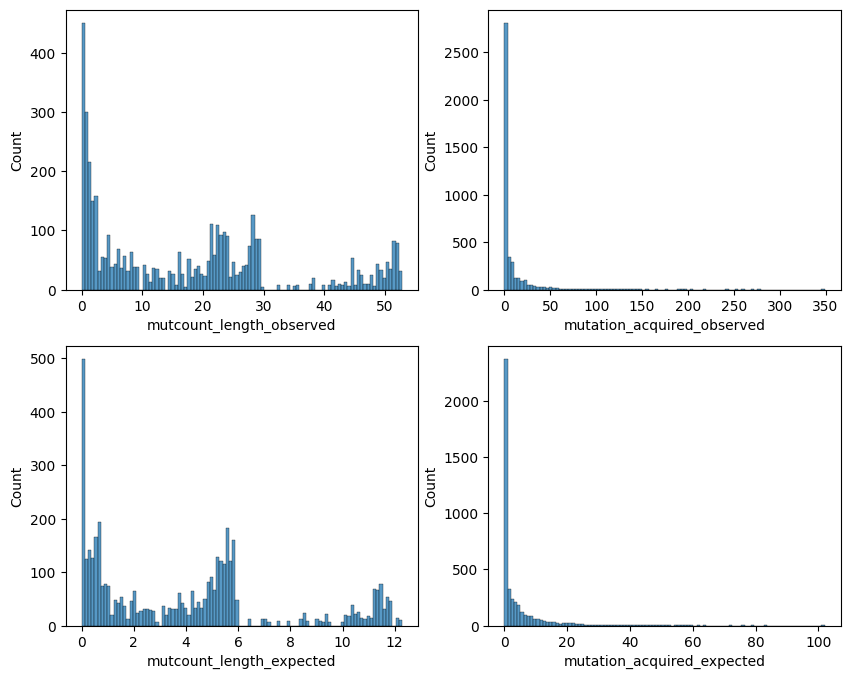

In [23]:
dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()

compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for ax, column in enumerate(['mutcount_length_observed', 'mutation_acquired_observed', 'mutcount_length_expected', 'mutation_acquired_expected']):
    sns.histplot(compare_dasm_rates[compare_dasm_rates.one_mutation_away == True][column], ax=axes[ax], bins=100)

In [24]:

def plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, savefig_prefix=None, title_extra=''):
    # Calculate regression statistics
    x = compare_dasm_rates['log_ratio']
    y = compare_dasm_rates['log_selection_factor']

    # Remove any NaN values for regression calculation
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value ** 2
    n = len(x_clean)


    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot regular points in blue
    sns.scatterplot(data=compare_dasm_rates,
                    x='log_ratio', y='log_selection_factor',
                    color='grey', alpha=0.3, label='Other sites')

    # filter entrenched data
    entrenched_compare_rates_dasm = pd.merge(entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), compare_dasm_rates, on=['site', 'v_family', 'parent_aa', 'child_aa'], how='inner')
    print(f"Plotting {len(entrenched_compare_rates_dasm)} entrenched points")
    # print which points were not found in the compare_dasm_rates
    not_found = pd.merge(entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), compare_dasm_rates, on=['site', 'v_family', 'parent_aa', 'child_aa'], how='outer', indicator=True)
    not_found = not_found[not_found['_merge'] == 'left_only']
    if len(not_found) > 0:
        print("The following entrenched points were not found in the comparison data:")
        print(not_found[['site', 'v_family', 'parent_aa', 'child_aa']])
    # plot entrenched points in color
    entrenched_compare_rates_dasm['site'] = entrenched_compare_rates_dasm['site'].astype(str)
    sns.scatterplot(data=entrenched_compare_rates_dasm,
                    x='log_ratio', y='log_selection_factor',
                    s=90, hue='site', style='v_family', palette=SITE_COLOR_MAP)

    # Add the regression line
    sns.regplot(data=compare_dasm_rates, x='log_ratio', y='log_selection_factor',
                scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)

    # Add legend
    plt.legend()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.xlabel('Observed Rate / Expected Rate (log)')
    plt.ylabel('DASM Selection Factor (log)')

    # Format the equation and R² for the title
    if intercept >= 0:
        equation = f'y = {slope:.3f}x + {intercept:.3f}'
    else:
        equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

    title = f'Comparison of Observed/Expected Rate Ratio vs DASM Selection Factor\nObserved from productive sequences, Expected from non-productive sequences\n{equation}, R² = {r_squared:.3f}, n = {n}\n{title_extra}'
    plt.title(title)

    plt.tight_layout()
    plt.show()
    if savefig_prefix:
        fig.savefig(f'figures/{savefig_prefix}validation_dasm_vs_rates_comparison_all.pdf', dpi=800)

    # # Convert from whatever type to float, then int, then string
    # compare_dasm_rates['site'] = compare_dasm_rates['site'].astype(float).astype(int).astype(str)
    # entrenched_compare_rates_dasm['site'] = entrenched_compare_rates_dasm['site'].astype(str)

    # fig, ax = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

    # # Get site order - they're already strings now, so convert to int for sorting
    # site_order = sorted(compare_dasm_rates['site'].unique(), key=lambda x: int(x))

    # # Create boxplots with grey color and alpha
    # sns.boxplot(data=compare_dasm_rates, x='site', y='mutation_acquired_expected', 
    #             ax=ax[0], whis=[5,95], showfliers=False, order=site_order, 
    #             color='grey')
    # sns.boxplot(data=compare_dasm_rates, x='site', y='mutation_acquired_observed', 
    #             ax=ax[1], whis=[5,95], showfliers=False, order=site_order, 
    #             color='grey')

    # # Overlay scatter points
    # sns.stripplot(data=entrenched_compare_rates_dasm, x='site', y='mutation_acquired_expected', 
    #             ax=ax[0], hue='site', palette=SITE_COLOR_MAP, 
    #             size=10, linewidth=1.5, edgecolor='black', dodge=False, order=site_order, legend=False, jitter=0.2)

    # sns.stripplot(data=entrenched_compare_rates_dasm, x='site', y='mutation_acquired_observed', 
    #             ax=ax[1], hue='site', palette=SITE_COLOR_MAP, 
    #             size=10, linewidth=1.5, edgecolor='black', dodge=False, order=site_order, legend=False, jitter=0.2)

    # # Increase font sizes
    # ax[0].tick_params(axis='both', labelsize=14)
    # ax[1].tick_params(axis='both', labelsize=14)
    # ax[0].set_ylabel('Mutations expected', fontsize=14)
    # ax[1].set_ylabel('Mutations observed', fontsize=14)
    # ax[1].set_xlabel('Site', fontsize=16)

    # # Rotate x-axis labels
    # ax[1].tick_params(axis='x', rotation=90)

    # # Add title
    # fig.suptitle(f'Mutation counts in productive and non productive data\nwith entrenched sites highlighted (all subtitutions)\n{title_extra}', 
    #             fontsize=18, y=0.995)

    # plt.tight_layout()
    # if savefig_prefix:
    #     fig.savefig(f'figures/{savefig_prefix}validation_rates_mutation_counts.pdf', dpi=800)


def plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, savefig_prefix=None, title_extra=''):
    fig, axes = plt.subplots(2, 3, figsize=(18, 7))
    fig.subplots_adjust(hspace=0.5, wspace=0.3, right=0.85, top=0.8)  # Make room on the right
    axes = axes.flatten()
    ax_i = 0
    
    # Collect all unique sites across all subplots
    all_sites = set()
    
    plot_order = ['IGHV1_vs_IGHV3', 'IGHV1_vs_IGHV4', 'IGHV3_vs_IGHV4', 'IGHV1_vs_IGHV1', 'IGHV3_vs_IGHV3', 'IGHV4_vs_IGHV4']

    for cur_pair_name in plot_order:
        cur_pairwise_df = pairwise_df_dict[cur_pair_name]
        # get entrenched sites
        cur_pairwise_df = cur_pairwise_df[cur_pairwise_df.are_both_less_than_minus1 == True]

        # create pairwise log ratio dataframe
        compare_dasm_rates1 = compare_dasm_rates[['v_family', 'site', 'parent_aa', 'child_aa', 'observed_counts', 'expected_counts', 'log_ratio']].copy().rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'child_aa':'parent_aa_2_and_target_aa_1'})
        compare_dasm_rates2 = compare_dasm_rates[['v_family', 'site', 'parent_aa', 'child_aa', 'observed_counts', 'expected_counts', 'log_ratio']].copy().rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'child_aa':'parent_aa_1_and_target_aa_2'})
        counts_pairwise = pd.merge(compare_dasm_rates1, compare_dasm_rates2,  on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], suffixes=('_1', '_2'))
        # merge with current entrenched sites according to DASM analysis
        entrenched_merged_pairwise = pd.merge(counts_pairwise, cur_pairwise_df, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2'], how='inner')
        
        # how many points were not found in the merge?
        not_found = pd.merge(cur_pairwise_df, counts_pairwise, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2'], how='outer', indicator=True)
        not_found = not_found[not_found['_merge'] == 'left_only']
        # if len(not_found) > 0:
        #     print(f"For pair {cur_pair_name}, the following entrenched points were not found in the comparison data:")
        #     print(not_found[['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2']])

        # plot pairwise comparison
        if len(not_found) == 0:
            axes[ax_i].set_title(f"{cur_pair_name.replace('_', ' ')}")
        else:
            axes[ax_i].set_title(f"{cur_pair_name.replace('_', ' ')}\n(missing {len(not_found)} entrenched site+aa pairs)", fontsize=12)
        entrenched_merged_pairwise['site'] = entrenched_merged_pairwise.site.astype(int).astype(str)
        
        # Collect all unique sites
        all_sites.update(entrenched_merged_pairwise['site'].unique())

        sns.scatterplot(counts_pairwise, x='log_ratio_1', y='log_ratio_2', color='grey', 
                       ax=axes[ax_i], alpha=0.3, label='Other sites')
        sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2', 
                       hue='site', palette=SITE_COLOR_MAP, ax=axes[ax_i], s=90)
        
        # Remove individual subplot legends
        if axes[ax_i].get_legend():
            axes[ax_i].get_legend().remove()
        
        axes[ax_i].axvline(0, color='black', linestyle=':', linewidth=1)
        axes[ax_i].axhline(0, color='black', linestyle=':', linewidth=1)
        axes[ax_i].set_xlabel(f'Log Ratio {cur_pair_name.split("_vs_")[0]}')
        axes[ax_i].set_ylabel(f'Log Ratio {cur_pair_name.split("_vs_")[1]}')
        ax_i += 1

    # make room for title
    fig.suptitle(f'Germline-divergent sites comparison of Observed/Expected Counts Ratios\nObserved from productive sequences, Expected from non-productive sequences\n{title_extra}')
    
    # Create legend handles for all unique sites
    legend_handles = []
    legend_labels = []
    
    # Add "Other sites" first
    legend_handles.append(plt.scatter([], [], color='grey', alpha=0.3))
    legend_labels.append('Other sites')
    
    # Add all unique sites in sorted order
    for site in sorted(all_sites, key=lambda x: int(x) if x.isdigit() else x):
        legend_handles.append(plt.scatter([], [], color=SITE_COLOR_MAP[site], s=90))
        legend_labels.append(site)
    
    # Create unified legend on the right side
    fig.legend(legend_handles, legend_labels, loc='center left', bbox_to_anchor=(0.87, 0.5), 
               frameon=True, title='Sites')
    
    fig.show()
    
    return

Plotting 129 entrenched points
The following entrenched points were not found in the comparison data:
      site v_family parent_aa child_aa
2021  55.0    IGHV1         L        R


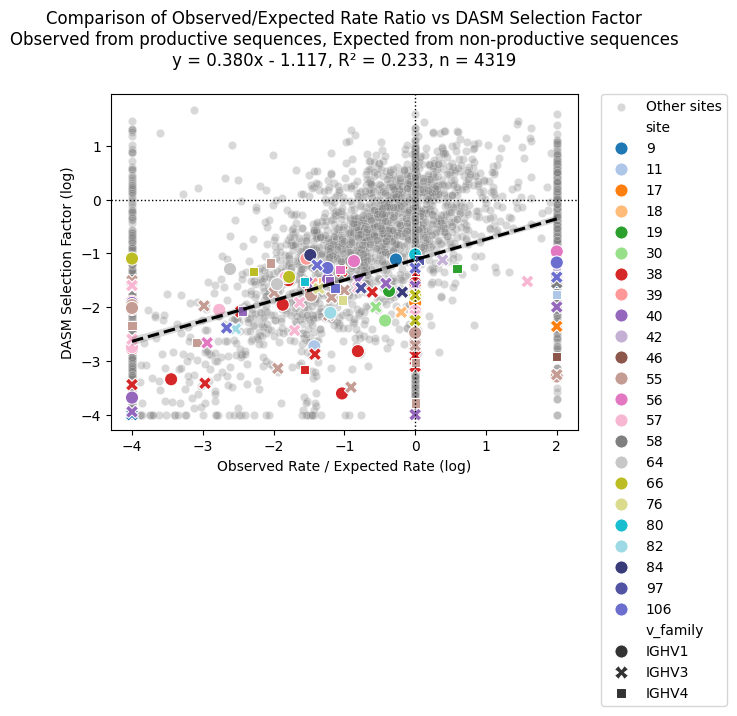

KeyError: "['observed_counts', 'expected_counts'] not in index"

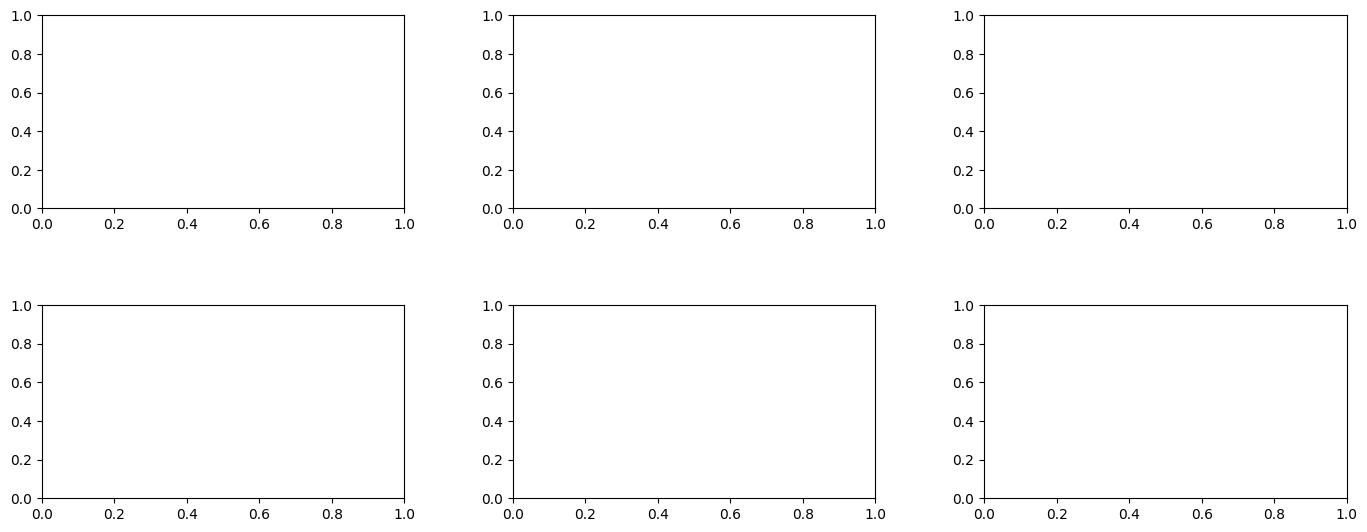

In [25]:
# Correlate all DASM selection factors with observed/expected rates for amino acid changes

dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()

compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

# filter only sites with one mutation away (and part of the v gene)
compare_dasm_rates = compare_dasm_rates[(compare_dasm_rates.one_mutation_away == True) & (compare_dasm_rates.site <= 106)]


plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, savefig_prefix=None, title_extra='')
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict)




In [ ]:
#compare_dasm_rates[(compare_dasm_rates.site == '40')  & (compare_dasm_rates.v_family == 'IGHV1') & (compare_dasm_rates.parent_aa == 'S')]
compare_dasm_rates[compare_dasm_rates.log_ratio >= 2]

,site,parent_aa,child_aa,rate_mutcount_observed,mutcount_length_observed,mutation_acquired_observed,v_family,one_mutation_away,rate_mutcount_expected,mutcount_length_expected,mutation_acquired_expected,ratio,log_ratio,selection_factor,log_selection_factor
9,1,Q,L,0.216994,23.042099,5,IGHV1,True,0.0,5.227343,0,217.994122,2.0,0.257119,-1.358218
21,1,E,D,3.145883,0.317876,1,IGHV1,True,0.0,0.002193,0,3146.882791,2.0,0.553615,-0.591287
64,1,E,K,0.047852,41.795441,2,IGHV3,True,0.0,8.442521,0,48.852110,2.0,0.100271,-2.299877
79,1,Q,E,0.105123,28.538130,3,IGHV4,True,0.0,5.573741,0,106.122514,2.0,0.184490,-1.690161
97,2,V,D,0.141191,21.247745,3,IGHV1,True,0.0,4.491716,0,142.191451,2.0,0.237710,-1.436705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10027,106,A,S,8.873166,0.112699,1,IGHV1,True,0.0,0.036830,0,8874.165959,2.0,1.677931,0.517562
10060,106,R,L,0.042990,23.261337,1,IGHV3,True,0.0,4.286861,0,43.989790,2.0,0.190987,-1.655548
10063,106,R,P,0.042990,23.261337,1,IGHV3,True,0.0,4.286861,0,43.989790,2.0,0.056503,-2.873462
10084,106,T,R,0.845397,1.182877,1,IGHV3,True,0.0,0.401141,0,846.396711,2.0,0.236165,-1.443226


In [ ]:
entrenched_sites_test = entrenched_compare_rates_dasm.site.drop_duplicates().sort_values().tolist()
entrenched_sites_that_pass_filter_test = entrenched_compare_rates_dasm[(entrenched_compare_rates_dasm.mutation_acquired_expected >= 5)].site.drop_duplicates().sort_values()

# find all sites that exist in entrenched_sites_test but not in entrenched_sites_that_pass_filter_test
print(set(entrenched_sites_test) - set(entrenched_sites_that_pass_filter_test))

# find all sites that exist in entrenched_sites_test and in entrenched_sites_that_pass_filter_test
print(set(entrenched_sites_test) & set(entrenched_sites_that_pass_filter_test))

{'18', '58', '17', '42', '46'}
{'80', '82', '97', '19', '56', '76', '106', '84', '64', '66', '9', '57', '40', '38', '11', '39', '30', '55'}


In [ ]:
sites_that_lost_data_when_filtering = compare_dasm_rates[(compare_dasm_rates.mutation_acquired_expected < 5)].site.drop_duplicates().sort_values()
all_sites = compare_dasm_rates.site.drop_duplicates().sort_values()

# find sites that do not lose substitutions to filtering
print(set(all_sites) - set(sites_that_lost_data_when_filtering))

{'67', '103'}


Plotting 39 entrenched points
The following entrenched points were not found in the comparison data:
       site v_family parent_aa child_aa
53      9.0    IGHV3         G        A
55      9.0    IGHV4         A        G
62     11.0    IGHV4         G        E
93     17.0    IGHV1         A        G
94     17.0    IGHV3         G        A
...     ...      ...       ...      ...
981    84.0    IGHV1         T        K
1149   97.0    IGHV4         A        E
1267  106.0    IGHV1         T        K
1273  106.0    IGHV3         T        K
1274  106.0    IGHV3         T        R

[91 rows x 4 columns]


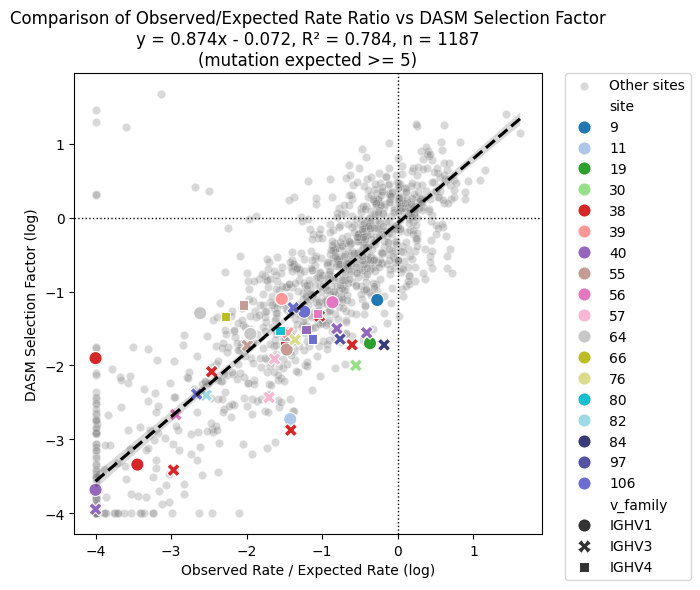

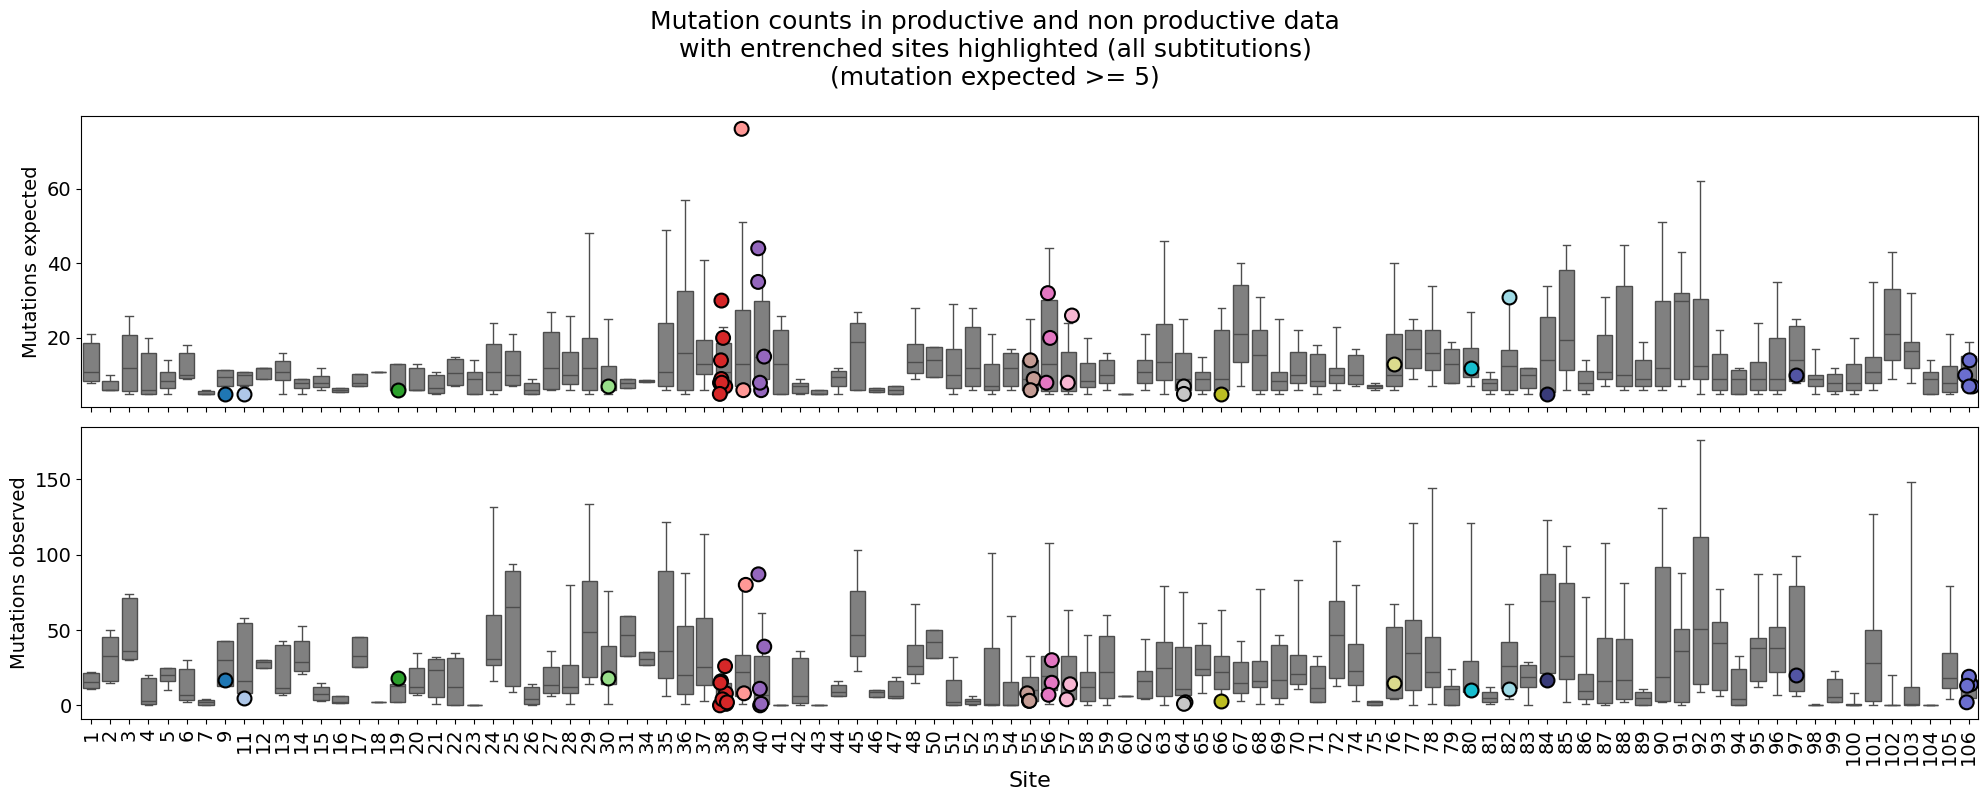

In [ ]:
# Correlate DASM selection factors with observed/expected rates for amino acid changes that pass filter (compare_dasm_rates['mutation_acquired_expected'] >= 5) & (compare_dasm_rates.one_mutation_away == True) & (compare_dasm_rates['mutcount_length_observed'] >= compare_dasm_rates['mutcount_length_expected'])

dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

# filter only sites with sufficient data, and one mutation away
compare_dasm_rates = compare_dasm_rates[(compare_dasm_rates['mutation_acquired_expected'] >= 5) & (compare_dasm_rates.one_mutation_away == True) & (compare_dasm_rates.site <= 106)]


plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, savefig_prefix=None, title_extra='(mutations expected >= 5)')
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, title_extra='(mutations expected >= 5)')

